In [1]:
from sklearn.cluster import KMeans
import pandas as pd
import pickle
import numpy as np
from matplotlib import pyplot as plt
from geoai.utils_geo.raster_ops import RasterOperations
from geoai.utils_ml.model_ops import ModelOperations
from geoai.utils_ds.preprocessing_ops import PreProcessingOperations
raster_ops = RasterOperations()
model_ops = ModelOperations()
pre_processing_ops = PreProcessingOperations()

In [2]:
X = pd.read_csv("csv_files/dataset_no_duplicates.csv").drop("Landcover", axis=1)
X.head()

,BLUE,GREEN,RED,NIR,SWIR
0,835.3333,920.7500,1301.0000,1478.6666,1976.75
1,938.6667,966.3333,1153.0000,1376.0000,2025.20
2,871.0000,902.0000,946.0000,1218.0000,2025.20
3,985.0000,1050.0000,1114.6666,1573.0000,1974.75
4,940.2500,994.5000,1046.0000,1256.5000,1976.75


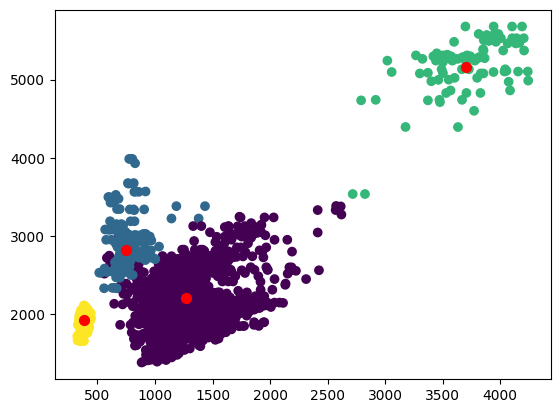

In [3]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
clusters_sk = kmeans.labels_
centroids_sk = kmeans.cluster_centers_
plt.scatter(X["BLUE"], X["SWIR"], c=clusters_sk)
plt.scatter(centroids_sk[:, 0], centroids_sk[:, 4],
                               marker='.', s=200, c='red')
plt.show()


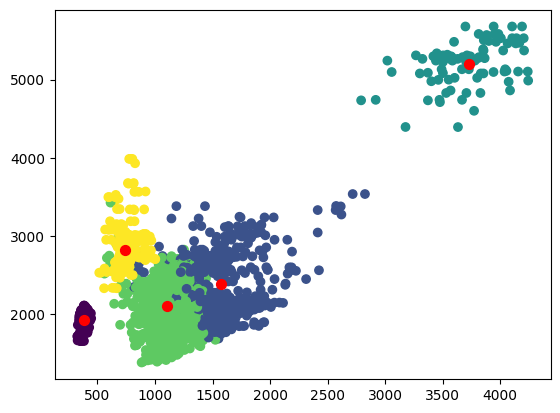

In [4]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)
clusters_sk = kmeans.labels_
centroids_sk = kmeans.cluster_centers_
plt.scatter(X["BLUE"], X["SWIR"], c=clusters_sk)
plt.scatter(centroids_sk[:, 0], centroids_sk[:, 4],
                               marker='.', s=200, c='red')
plt.show()


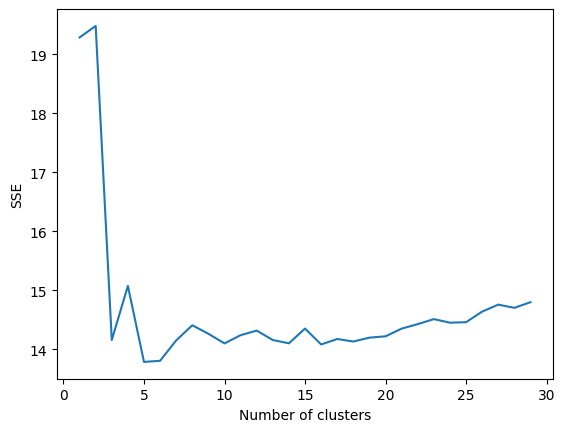

In [5]:
X_scaled = pre_processing_ops.scale_to_minmax(X)
k_list = list(range(1, 30))
sse_list = [0] * len(k_list)
for k_ind, k in enumerate(k_list):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    clusters = kmeans.labels_
    centroids = kmeans.cluster_centers_
    sse = 0
    for i in range(k):
        cluster_i = np.where(clusters == i)
        sse += np.linalg.norm(X_scaled.values[cluster_i] - centroids[i])
    sse_list[k_ind] = sse
plt.plot(k_list, sse_list)
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.show()


In [6]:
kmeans_4 = KMeans(n_clusters=4)
kmeans_4.fit(X)

kmeans_5 = KMeans(n_clusters=5)
kmeans_5.fit(X)

with open("trained_models/kmeans_4.pkl", "wb") as file:
    pickle.dump(kmeans_4, file)

with open("trained_models/kmeans_5.pkl", "wb") as file:
    pickle.dump(kmeans_5, file)

END